In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
sys.path.append("../")

import os
import re
import six
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter, FuncFormatter
import seaborn as sns
from scorecardpipeline import *


init_setting()

### 三方数据评估报告输出

In [2]:
# 参考: https://scorecardpipeline.itlubber.art/scorecardpipeline.html#module-scorecardpipeline.auto_report
# pip install scorecardpipeline -i https://pypi.org/simple

from scorecardpipeline import *

# 初始化设置，包含忽略warning、画图字体、[随机种子、日志输出]
init_setting()

# 加载数据集，标签转换为 0 和 1
target = "creditability"
data = germancredit()
data[target] = data[target].map({"good": 0, "bad": 1})
features = data.columns.drop(target).tolist()

# 测试报告输出
auto_data_testing_report(data
                         , features=features
                         , target=target
                         , date=None # 传入日期列名，会按 freq 统计不同时间维度好坏样本的分布情况
                         , freq="M"
                         , data_summary_comment=""
                         , excel_writer="model_report/三方数据测试报告.xlsx"
                         , sheet="分析报告"
                         , start_col=2
                         , start_row=2
                         , writer_params={}
                         , bin_params={"method": "dt", "min_bin_size": 0.05, "max_n_bins": 10} # feature_bin_stats 函数的相关参数
                         , pictures=['bin', 'ks', 'hist'] # 类别型变量不支持 ks 和 hist
                         , corr=True
                         )

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:09<00:00,  2.13it/s, feature=duration_in_month]


(742, 22)

In [3]:
from scorecardpipeline import *

# 初始化设置，包含忽略warning、画图字体、[随机种子、日志输出]
init_setting()

# 加载数据集，标签转换为 0 和 1
target = "creditability"
data = germancredit()
data[target] = data[target].map({"good": 0, "bad": 1})
features = data.columns.drop(target).tolist()

ruleset_report(data, rules=[Rule('credit_amount < 2000'), Rule('age_in_years < 25')], target=target, overdue=[target], dpd=[0])

规则详情              creditability DPD0+                                                                             
                     分箱  样本总数   样本占比                好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数
0                  原始样本  1000 1.0000                 700 1.0000  300 1.0000 0.3000 1.0000  1.0000  1.0000    NaN    NaN    NaN    NaN
1  credit_amount < 2000   432 0.4320                 311 0.4443  121 0.4033 0.2801 0.9336 -0.0505 -0.1168 0.5100 0.2801 0.4033 0.3306
2                  剩余样本   568 0.5680                 389 0.5557  179 0.5967 0.3151 1.0505  0.0664  0.1168 0.4900 0.3151 0.5967 0.4124
3     age_in_years < 25    75 0.1320                  43 0.1105   32 0.1788 0.4267 1.3539  0.0538  0.4077 0.6655 0.4267 0.1788 0.2520
4                  剩余样本   493 0.8680                 346 0.8895  147 0.8212 0.2982 0.9462 -0.3539 -0.4077 0.3345 0.2982 0.8212 0.4375
5                    汇总   507 0.5070                 354 0.5057  153 0.5100 0.3018 1.0059  0.0061  0.0120 0.4990 0.3018 0.5100 0.3792

In [4]:
swap_in_data, swap_in_data_amount = sawpin_badrate_prediction_by_score(
    data, data.sample(n=500), [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')], "credit_amount", 
    target=target, amount="credit_amount"
)

swap_in_data

,样本总数,样本占比,坏样本数,坏样本率,LIFT值,坏账改善,风险拒绝比
规则详情,,,,,,,
原始样本,134.0000,0.2680,37.3814,0.2790,0.9338,0.0662,0.2469
((credit_amount > 2000) & (age_in_years > 25)) | (duration_in_month > 12),366.0000,0.7320,111.9854,0.3060,1.0242,-0.0242,-0.0331
置换样本,500.0000,1.0000,149.3668,0.2987,1.0000,0.0000,0.0000


In [5]:
swap_in_data, swap_in_data_amount = sawpin_badrate_prediction_by_score(
    data, data.sample(n=500), [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')], "credit_amount", 
    overdue=target, dpd=[0, 1], amount="credit_amount"
)

swap_in_data

规则详情        creditability 0+                               creditability 1+                        
                                                                              样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比             坏样本数   坏样本率 LIFT值 坏账改善 风险拒绝比
规则详情                                                                                                                                                                             
原始样本                                                                      135.0000 0.2700          38.1464 0.2826 0.9341  0.0659  0.2441           0.0000 0.0000   NaN  NaN   NaN
((credit_amount > 2000) & (age_in_years > 25)) | (duration_in_month > 12) 365.0000 0.7300         113.1043 0.3099 1.0244 -0.0244 -0.0334           0.0000 0.0000   NaN  NaN   NaN
置换样本                                                                      500.0000 1.0000         151.2508 0.3025 1.0000  0.0000  0.0000           0.0000 0.0000   NaN  NaN   NaN

In [6]:
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

swap_in_data = data.sample(n=500)

report, report_amount = swapin_report(
    data,
    swap_in_data,
    swap_in_ruleset,
    "credit_amount",
    target=target,
    amount="credit_amount",
)

display(report)

report, report_amount = swapin_report(
    data,
    swap_in_data,
    swap_in_ruleset,
    "credit_amount",
    overdue=[target],
    dpd=[0],
    amount="credit_amount",
)

display(report_amount)

,样本总数,样本占比,坏样本数,坏样本率,LIFT值,坏账改善,风险拒绝比
规则详情,,,,,,,
原始样本,138.0000,1.0000,38.2891,0.2775,1.0000,0.0000,0.0000
(credit_amount > 2000) & (age_in_years > 25),227.0000,1.6449,72.9997,0.3216,1.1590,-0.0989,-0.0601
置换样本,365.0000,2.6449,111.2888,0.3049,1.0989,-0.0718,-0.0271
duration_in_month > 12,135.0000,0.9783,38.1213,0.2824,1.0177,-0.0088,-0.0090
通过样本,500.0000,3.6232,149.4101,0.2988,1.0770,-0.0603,-0.0167


规则详情        creditability 0+                              
                                                     样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                           
原始样本                                          163185.0000 1.0000       43447.4560 0.2662 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 1074963.0000 6.5874      393138.7211 0.3657 1.3736 -0.3244 -0.0492
置换样本                                         1238148.0000 7.5874      436586.1771 0.3526 1.3244 -0.2866 -0.0378
duration_in_month > 12                        340819.0000 2.0885      112149.5052 0.3291 1.2359 -0.1595 -0.0764
通过样本                                         1578967.0000 9.6759      548735.6823 0.3475 1.3053 -0.2767 -0.0286

In [7]:
swap_in_ruleset = [Rule('duration_in_month > 12'), Rule('credit_amount > 2000') & Rule('age_in_years > 25')]
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

report = pd.DataFrame()

swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    data,
    swap_in_data_temp,
    swap_in_ruleset,
    "credit_amount",
    overdue=[target],
    dpd=[0],
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         130.0000 1.0000          37.2559 0.2866 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 239.0000 1.8385          77.6332 0.3248 1.1334 -0.0864 -0.0470
置换样本                                         369.0000 2.8385         114.8891 0.3114 1.0864 -0.0639 -0.0225
duration_in_month > 12                       131.0000 1.0077          37.2299 0.2842 0.9917  0.0042  0.0041
通过样本                                         500.0000 3.8462         152.1190 0.3042 1.0616 -0.0489 -0.0127

In [8]:
# swap_in_ruleset = [Rule('duration_in_month > 12'), Rule('credit_amount > 2000') & Rule('age_in_years > 25')]
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

report = pd.DataFrame()

swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    data,
    swap_in_data_temp,
    swap_in_ruleset,
    "credit_amount",
    overdue=[target],
    dpd=[0],
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         133.0000 1.0000          37.8680 0.2847 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 226.0000 1.6992          73.2985 0.3243 1.1391 -0.0876 -0.0515
置换样本                                         359.0000 2.6992         111.1665 0.3097 1.0876 -0.0639 -0.0237
duration_in_month > 12                       141.0000 1.0602          40.1197 0.2845 0.9993  0.0003  0.0003
通过样本                                         500.0000 3.7594         151.2861 0.3026 1.0627 -0.0495 -0.0132

In [9]:
swap_in_ruleset = [Rule('duration_in_month > 12'), Rule('credit_amount > 2000') & Rule('age_in_years > 25')]

report = pd.DataFrame()

# swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    data,
    swap_in_data_temp,
    swap_in_ruleset,
    "credit_amount",
    overdue=[target],
    dpd=[0],
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         133.0000 1.0000          37.8680 0.2847 1.0000  0.0000  0.0000
duration_in_month > 12                       319.0000 2.3985          99.6021 0.3122 1.0966 -0.0682 -0.0284
置换样本                                         452.0000 3.3985         137.4701 0.3041 1.0682 -0.0527 -0.0155
(credit_amount > 2000) & (age_in_years > 25)  48.0000 0.3609          13.8160 0.2878 1.0109 -0.0029 -0.0080
通过样本                                         500.0000 3.7594         151.2861 0.3026 1.0627 -0.0495 -0.0132

### 自动EDA输出报告

In [10]:
# https://scorecardpipeline.itlubber.art/scorecardpipeline.html#module-scorecardpipeline.auto_eda
from scorecardpipeline import *

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

# 自动 eda 并保存文件
auto_eda_sweetviz(data, target=target, save="model_report/auto_eda.html")

Done! Use 'show' commands to display/save.   |██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| [100%]   00:00 -> (00:00 left)

Report model_report/auto_eda.html was generated.


In [11]:
init_setting()

分箱详情                                                        creditability 0+                             
            指标名称               指标含义                  分箱     样本总数   样本占比             坏样本数   坏样本率  LIFT值 累积LIFT值  分档KS值
0  credit_amount  样本数 1000 坏样本率 0.3       [负无穷 , 605.0)  24.0000 0.0240           3.0000 0.1250 0.4167  1.0000 0.0000
1  credit_amount  样本数 1000 坏样本率 0.3    [605.0 , 3913.5) 716.0000 0.7160         186.0000 0.2598 0.8659  1.0143 0.0200
2  credit_amount  样本数 1000 坏样本率 0.3   [3913.5 , 6193.0) 117.0000 0.1170          44.0000 0.3761 1.2536  1.4231 0.1571
3  credit_amount  样本数 1000 坏样本率 0.3  [6193.0 , 10918.0) 112.0000 0.1120          45.0000 0.4018 1.3393  1.5618 0.1148
4  credit_amount  样本数 1000 坏样本率 0.3     [10918.0 , 正无穷)  31.0000 0.0310          22.0000 0.7097 2.3656  2.3656 0.0605
5  credit_amount  样本数 1000 坏样本率 0.3                 缺失值   0.0000 0.0000           0.0000 0.0000 0.0000  0.0000 0.0000

分箱详情                                            creditability 0+                              
             指标名称 指标含义                    分箱     样本总数   样本占比             坏样本数   坏样本率  LIFT值 累积LIFT值   分档KS值
0   credit_amount             [负无穷 , 425.83)  10.0000 0.0100           0.0000 0.0000 0.0000  1.0000  0.0000
1   credit_amount          [425.83 , 570.02)  10.0000 0.0100           3.0000 0.3000 1.0000  1.0101  0.0143
2   credit_amount           [570.02 , 638.7)  10.0000 0.0100           2.0000 0.2000 0.6667  1.0102  0.0143
3   credit_amount           [638.7 , 708.95)  20.0000 0.0200           7.0000 0.3500 1.1667  1.0137  0.0190
4   credit_amount           [708.95 , 932.0)  49.0000 0.0490          19.0000 0.3878 1.2925  1.0105  0.0143
5   credit_amount           [932.0 , 1262.0)  99.0000 0.0990          30.0000 0.3030 1.0101  0.9952 -0.0062
6   credit_amount          [1262.0 , 1906.8) 202.0000 0.2020          48.0000 0.2376 0.7921  0.9933 -0.0076
7   credit_amount       [1906.8 , 2852.3999) 200.0000 0.2000          54.0000 0.2700 0.9000  1.0611  0.0524
8   credit_amount       [2852.3999 , 4720.0) 200.0000 0.2000          52.0000 0.2600 0.8667  1.1417  0.0810
9   credit_amount             [4720.0 , 正无穷) 200.0000 0.2000          85.0000 0.4250 1.4167  1.4167  0.1190
10  credit_amount                        缺失值   0.0000 0.0000           0.0000 0.0000 0.0000  0.0000  0.0000

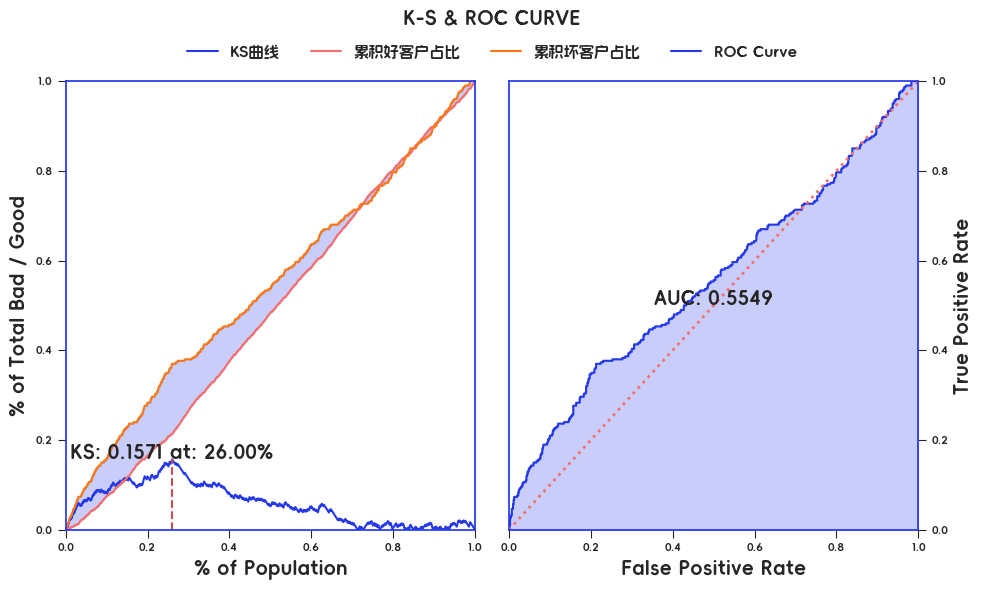

In [12]:
feature_efficiency_analysis(data, 'credit_amount', overdue=[target], dpd=[0], ks=True)

### 特征区分度

In [13]:
from scorecardpipeline import *

# 初始化配置
init_setting()

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

use_cols = ['指标名称', '指标含义', '分箱', '样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', '分档WOE值', '指标IV值', 'LIFT值', '坏账改善', '累积LIFT值', '累积坏账改善', '分档KS值']

# 使用 MDLP 自动分箱查看特征区分度
table_mdlp = feature_bin_stats(data, "duration_in_month", target=target, method="mdlp", desc="在账月份", max_n_bins=5)[use_cols]
bin_plot(table_mdlp, desc="在账月份 MDLP ", save="model_report/duration_in_month_mdlp_binplot.png")

# 使用 step 验证特征泛化能力
table_step = feature_bin_stats(data, "duration_in_month", target=target, method="step", desc="在账月份", max_n_bins=5)[use_cols]
bin_plot(table_step, desc="在账月份 STEP ", save="model_report/duration_in_month_step_binplot.png")

# 初始化 Excel 写入器
writer = ExcelWriter()

end_row, end_col = dataframe2excel(table_mdlp,
                                   writer,
                                   sheet_name="分箱信息",
                                   percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "坏账改善", "累积坏账改善"],
                                   condition_cols=["坏样本率", "LIFT值"],
                                   start_row=2,
                                   merge_column=["指标名称", "指标含义", "指标IV值"],
                                   merge=True,
                                   title="duration_in_month（在账月份） MDLP 特征区分度",
                                   figures=[f"model_report/duration_in_month_mdlp_binplot.png"])

end_row, end_col = dataframe2excel(table_step,
                                   writer,
                                   sheet_name="分箱信息",
                                   percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "坏账改善", "累积坏账改善"],
                                   condition_cols=["坏样本率", "LIFT值"],
                                   start_row=end_row + 2,
                                   merge_column=["指标名称", "指标含义", "指标IV值"],
                                   merge=True,
                                   title="duration_in_month（在账月份） STEP 特征区分度",
                                   figures=[f"model_report/duration_in_month_step_binplot.png"])

# 保存到 excel 文件
writer.save("model_report/数据有效性之特征区分度.xlsx")

In [14]:
# 随机生成逾期天数，模拟客户逾期数据
data["MOB1"] = np.where(np.random.random(len(data)) <= 0.8, 0, np.random.randint(1, 31, size=len(data)))

table = feature_bin_stats(data, "duration_in_month", overdue=["MOB1"], dpd=[0, 3], method="mdlp", max_n_bins=5, empty_separate=True, return_rules=False, del_grey=True, return_cols=['样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '累积LIFT值', '坏账改善', '累积坏账改善', '分档KS值'])

percent_cols = ["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "坏账改善", "累积LIFT值", "累积坏账改善"]
condition_cols = ["坏样本率", "LIFT值"]

dataframe2excel(table
                , "model_report/数据有效性之特征区分度.xlsx"
                , percent_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in percent_cols) or (not isinstance(c, tuple) and c in percent_cols)]
                , condition_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in condition_cols) or (not isinstance(c, tuple) and c in condition_cols)]
                )

table

分箱详情                      MOB1 0+                                               ...  MOB1 3+                                                                  
                指标名称 指标含义             分箱     样本总数   样本占比     好样本数  好样本占比    坏样本数  坏样本占比   坏样本率  ...     好样本数  好样本占比    坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善 累积LIFT值 累积坏账改善  分档KS值
0  duration_in_month        [负无穷 , 13.5) 363.0000 0.3630 278.0000 0.3428 85.0000 0.4497 0.2342  ... 278.0000 0.3428 79.0000 0.4593 0.2213 1.2647  0.1509  1.2647 0.1509 0.1165
1  duration_in_month       [13.5 , 25.0) 407.0000 0.4070 335.0000 0.4131 72.0000 0.3810 0.1769  ... 335.0000 0.4131 64.0000 0.3721 0.1604 0.9167 -0.0569  1.0810 0.2699 0.0755
2  duration_in_month       [25.0 , 46.0) 165.0000 0.1650 140.0000 0.1726 25.0000 0.1323 0.1515  ... 140.0000 0.1726 23.0000 0.1337 0.1411 0.8064 -0.0385  1.0323 0.4642 0.0366
3  duration_in_month        [46.0 , 正无穷)  65.0000 0.0650  58.0000 0.0715  7.0000 0.0370 0.1077  ...  58.0000 0.0715  6.0000 0.0349 0.0938 0.5358 -0.0323  1.0000 1.0000 0.0000
4  duration_in_month                 缺失值   0.0000 0.0000   0.0000 0.0000  0.0000 0.0000 0.0000  ...   0.0000 0.0000  0.0000 0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000

[5 rows x 27 columns]

### 模型增益效果评估

In [15]:
# 选择需要评估的特征集
feature = ["duration_in_month"]

def calculate_model_score(data, target="target"):
    # 构建 pipeline
    model_pipeline = Pipeline([
        ("preprocessing", FeatureSelection(target=target, engine="toad")),
        ("combiner", Combiner(target=target, min_bin_size=0.1, max_n_bins=5, method="mdlp")),
        ("transform", WOETransformer(target=target)),
        ("processing_select", FeatureSelection(target=target, engine="toad")),
        ("stepwise", StepwiseSelection(target=target)),
        ("logistic", ITLubberLogisticRegression(target=target)),
    ])

    # 训练 pipeline
    model_pipeline.fit(data)

    # 计算模型指标
    return KS(model_pipeline.predict_proba(data)[:, -1], data[target])

# 计算模型指标增益效果
improvement = calculate_model_score(data, target=target) - calculate_model_score(data.drop(columns=feature), target=target)

print(f"特征: duration_in_month 在账月份 KS 增益效果 {improvement * 100:.4f}%")

特征: duration_in_month 在账月份 KS 增益效果 0.3333%


### 规则增益效果评估

In [16]:
from scorecardpipeline import *

# 初始化配置
init_setting()

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

# 随机生成逾期天数，模拟客户逾期数据
data["MOB1"] = np.where(np.random.random(len(data)) <= 0.8, 0, np.random.randint(1, 31, size=len(data)))

In [17]:
rule = Rule("duration_in_month > 43.5")
rule.report(data[["duration_in_month", target]], target=target)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,duration_in_month > 43.5,命中,70,0.0700,30,0.0429,40,0.1333,0.5714,1.9048,0.0681,0.9729,0.7100,0.5714,0.1333,0.2162
1,验证规则,duration_in_month > 43.5,未命中,930,0.9300,670,0.9571,260,0.8667,0.2796,0.9319,-0.9048,-0.9729,0.2900,0.2796,0.8667,0.4228


In [18]:
rule = Rule("duration_in_month > 43.5")
rule.report(data[["duration_in_month", "MOB1"]], overdue=["MOB1"], dpd=[0, 3, 7, 15], filter_cols=['坏样本率', 'LIFT值', '坏账改善', '样本占比'], del_grey=False)

规则详情                                            MOB1 DPD0+                MOB1 DPD3+                MOB1 DPD7+                MOB1 DPD15+               
   规则分类                      指标名称   分箱 样本总数   样本占比       坏样本率  LIFT值    坏账改善       坏样本率  LIFT值    坏账改善       坏样本率  LIFT值    坏账改善        坏样本率  LIFT值    坏账改善
0  验证规则  duration_in_month > 43.5   命中   70 0.0700     0.2571 1.1635  0.0123     0.2571 1.2857  0.0215     0.2143 1.2245  0.0169      0.1286 1.0989  0.0074
1  验证规则  duration_in_month > 43.5  未命中  930 0.9300     0.2183 0.9877 -0.1635     0.1957 0.9785 -0.2857     0.1720 0.9831 -0.2245      0.1161 0.9926 -0.0989

In [19]:
prior_rules = Rule("credit_amount > 3972.25")
rule.report(data[["duration_in_month", "credit_amount", target]], target=target, prior_rules=prior_rules)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,先验规则,credit_amount > 3972.25,命中,250,0.2500,145,0.2071,105,0.3500,0.4200,1.4000,0.1333,0.5333,0.6600,0.4200,0.3500,0.3818
1,先验规则,credit_amount > 3972.25,未命中,750,0.7500,555,0.7929,195,0.6500,0.2600,0.8667,-0.4000,-0.5333,0.3400,0.2600,0.6500,0.3714
0,验证规则,duration_in_month > 43.5,命中,11,0.0147,4,0.0072,7,0.0359,0.6364,2.4476,0.0215,1.4691,0.7440,0.6364,0.0359,0.0680
1,验证规则,duration_in_month > 43.5,未命中,739,0.9853,551,0.9928,188,0.9641,0.2544,0.9785,-1.4476,-1.4691,0.2560,0.2544,0.9641,0.4026


In [20]:
pd.set_option('display.max_columns', None)

In [21]:
prior_rules = Rule("credit_amount > 3972.25")
rule = Rule("duration_in_month > 43.5")

rule.report(data[["duration_in_month", "credit_amount", "MOB1"]], overdue=["MOB1"], dpd=[0, 3, 7, 15], prior_rules=prior_rules, filter_cols=['坏样本数', '坏样本率', 'LIFT值', '坏账改善', '样本占比'], del_grey=True)

规则详情                                MOB1 DPD0+                            MOB1 DPD3+                            MOB1 DPD7+                            MOB1 DPD15+                           
   规则分类                      指标名称   分箱       样本占比 坏样本数   坏样本率  LIFT值    坏账改善       样本占比 坏样本数   坏样本率  LIFT值    坏账改善       样本占比 坏样本数   坏样本率  LIFT值    坏账改善        样本占比 坏样本数   坏样本率  LIFT值    坏账改善
0  先验规则   credit_amount > 3972.25   命中     0.2500   54 0.2160 0.9774 -0.0075     0.2503   49 0.2000 0.9790 -0.0070     0.2526   45 0.1867 1.0179  0.0061      0.2500   28 0.1250 0.9573 -0.0142
1  先验规则   credit_amount > 3972.25  未命中     0.7500  167 0.2227 1.0075  0.0226     0.7497  151 0.2057 1.0070  0.0210     0.7474  130 0.1823 0.9939 -0.0179      0.7500   89 0.1324 1.0142  0.0427
2  验证规则  duration_in_month > 43.5   命中     0.0147    7 0.6364 2.8579  0.0277     0.0150    7 0.6364 3.0933  0.0318     0.0112    4 0.5000 2.7423  0.0198      0.0089    2 0.3333 2.5169  0.0137
3  验证规则  duration_in_month > 43.5  未命中     0.9853  160 0.2165 0.9723 -1.8579     0.9850  144 0.1992 0.9682 -2.0933     0.9888  126 0.1787 0.9802 -1.7423      0.9911   87 0.1306 0.9863 -1.5169

In [22]:
# all_data = load_pickle("/Users/lubberit/Desktop/workspace/scorecardpipeline/examples/all_data_qhyp.pkl")
# rule = Rule("(X1 < 588.5) & (X2 < 509.5)")
# prior_rule = Rule("放款金额 < 5000")
# all_data["target"] = (all_data["MOB1"] > 0).astype(int)
# table = rule.report(all_data[["X1", "X2", "放款金额", "MOB1", "target"]]
#                     , overdue=["MOB1"]
#                     , dpd=[0, 1, 2, 3, 4]
#                     , prior_rules=prior_rule
#                     # , filter_cols=['好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '坏账改善']
#                     )
# print(table)

# percent_cols = ["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "坏账改善", "累积LIFT值", "累积坏账改善"]
# condition_cols = ["坏样本率", "LIFT值"]
# dataframe2excel(table, "规则有效性验证.xlsx", percent_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in percent_cols) or (not isinstance(c, tuple) and c in percent_cols)]
#                 , condition_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in condition_cols) or (not isinstance(c, tuple) and c in condition_cols)]
#                 )
